# ECMM422J Coursework 2 — California Housing Price Prediction

**Student ID:** XXXXXXXX

This notebook develops unsupervised and supervised machine learning models to
predict the median house value of California districts (1990 U.S. Census data).

**Pipeline:**
1. Setup
2. Data loading
3. Exploratory data analysis
4. Preprocessing & feature engineering
5. Visualisation
6. Train/test split
7. Clustering (K-Means + KNN)
8. Regression (Linear, Random Forest, SVR)
9. Evaluation & comparison
10. Multi-Layer Perceptron (MLP)

## 1. Setup

Import libraries, fix the random seed for reproducibility, and set consistent
plotting defaults.

In [2]:
# Stage 1: Setup - imports, reproducibility, plotting defaults


import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility: fix the random seed everywhere so results are
# identical on every rerun (required for a reproducible submission).
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot defaults — applied once so every figure looks consistent.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

# Show all dataframe columns when printing (we have 10+).
pd.set_option("display.max_columns", None)

print("Setup complete.")
print("pandas:", pd.__version__, "| numpy:", np.__version__)

Setup complete.
pandas: 3.0.3 | numpy: 2.4.6


## 2. Data Loading

Load the California Housing dataset reproducibly: use the local copy in `data/`
if present, otherwise download it from the original source. This lets the
notebook run on a clean machine while keeping a version-controlled local copy.

In [3]:
# Stage 2: Data loading (reproducible: local copy or download)


import tarfile
import urllib.request

DATA_DIR = "../data"                       # repo's data/ folder
CSV_PATH = os.path.join(DATA_DIR, "housing.csv")
SOURCE_URL = "https://github.com/ageron/data/raw/main/housing.tgz"

def load_housing_data():
    """Return the housing DataFrame, downloading the dataset if needed."""
    if not os.path.exists(CSV_PATH):
        print("Local CSV not found — downloading from source...")
        os.makedirs(DATA_DIR, exist_ok=True)
        tgz_path = os.path.join(DATA_DIR, "housing.tgz")
        urllib.request.urlretrieve(SOURCE_URL, tgz_path)
        with tarfile.open(tgz_path) as tgz:
            tgz.extractall(path=DATA_DIR)
        # The archive extracts to data/housing/housing.csv — move it up.
        extracted = os.path.join(DATA_DIR, "housing", "housing.csv")
        if os.path.exists(extracted):
            os.replace(extracted, CSV_PATH)
        print("Download complete.")
    else:
        print("Loading local copy from", CSV_PATH)
    return pd.read_csv(CSV_PATH)

housing = load_housing_data()
print("Loaded:", housing.shape[0], "rows ×", housing.shape[1], "columns")
housing.head()

Loading local copy from ../data/housing.csv
Loaded: 20640 rows × 10 columns


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Exploratory Data Analysis

Before any preprocessing, inspect the dataset to understand its structure and
identify issues that must be handled. We specifically check for:

- **Feature types** — nine numeric features and one categorical (`ocean_proximity`).
- **Missing values** — which columns, how many.
- **Distribution artefacts** — capped values that are census artefacts, not true data.
- **Categorical balance** — how the `ocean_proximity` levels are distributed.

These findings directly justify the preprocessing decisions made in Section 4.

In [4]:
# Stage 3a: Structure, dtypes, and summary statistics



print("Dataset shape:", housing.shape)
print("\n--- Column types ---")
print(housing.dtypes)

print("\n--- Summary statistics (numeric features) ---")
display(housing.describe())

Dataset shape: (20640, 10)

--- Column types ---
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

--- Summary statistics (numeric features) ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
# Stage 3b: Missing values



missing = housing.isnull().sum()
missing_pct = (missing / len(housing) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
print("Missing values per column:")
display(missing_table[missing_table["missing_count"] > 0])

print(f"\nTotal rows: {len(housing)}")
print("Only 'total_bedrooms' has missing values "
      f"({missing['total_bedrooms']} rows, "
      f"{missing_pct['total_bedrooms']}% of data).")

Missing values per column:


,missing_count,missing_%
total_bedrooms,207,1.0



Total rows: 20640
Only 'total_bedrooms' has missing values (207 rows, 1.0% of data).


In [6]:
# Stage 3c: Capped-value artefacts
# These are census/collection artefacts, not genuine values, and
# they limit how well any regressor can fit the upper range.



target = "median_house_value"
mx_val = housing[target].max()
n_capped = (housing[target] == mx_val).sum()
print(f"Target capped at {mx_val}: {n_capped} rows "
      f"({n_capped/len(housing)*100:.1f}% sit exactly at the ceiling).")

mx_age = housing["housing_median_age"].max()
n_age = (housing["housing_median_age"] == mx_age).sum()
print(f"housing_median_age capped at {mx_age}: {n_age} rows "
      f"({n_age/len(housing)*100:.1f}%).")

Target capped at 500001.0: 965 rows (4.7% sit exactly at the ceiling).
housing_median_age capped at 52.0: 1273 rows (6.2%).


In [7]:
# Stage 3d: Categorical feature balance



print("ocean_proximity value counts:")
display(housing["ocean_proximity"].value_counts())

print("\nNote: 'ISLAND' has only 5 records — a rare category that "
      "must be handled carefully in the train/test split and encoding.")

ocean_proximity value counts:


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Note: 'ISLAND' has only 5 records — a rare category that must be handled carefully in the train/test split and encoding.


## 4. Preprocessing & Feature Engineering

We separate transformations into two groups to prevent data leakage:

- **Row-wise, non-learned transforms (done now):** these depend only on each
  row's own values, so they cannot leak information between train and test.
  - Feature engineering: per-household ratio features.
  - Categorical encoding: one-hot encoding of `ocean_proximity`.

- **Learned transforms (deferred to Section 6, after the split):** these estimate
  statistics from data and **must be fitted on the training set only**.
  - Median imputation of `total_bedrooms`.
  - Feature scaling (StandardScaler).

We also keep a copy of the capped-target flag so we can later test (ablation)
whether removing capped records improves model performance, rather than assuming
it does.

In [8]:
# Stage 4a: Feature engineering — per-household ratios
#
# Rationale: total_rooms, total_bedrooms and population are block-group
# TOTALS, so they mostly encode block size rather than housing quality.
# Normalising them per household / per room yields features that should
# correlate more directly with median_house_value. We will VERIFY this
# in the visualisation stage (correlation before vs after) rather than
# assume it.


housing = housing.copy()

housing["rooms_per_household"]      = housing["total_rooms"]    / housing["households"]
housing["bedrooms_per_room"]        = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"]  = housing["population"]      / housing["households"]

print("Added engineered features:")
print(housing[["rooms_per_household", "bedrooms_per_room",
               "population_per_household"]].describe())

Added engineered features:
       rooms_per_household  bedrooms_per_room  population_per_household
count         20640.000000       20433.000000              20640.000000
mean              5.429000           0.213039                  3.070655
std               2.474173           0.057983                 10.386050
min               0.846154           0.100000                  0.692308
25%               4.440716           0.175427                  2.429741
50%               5.229129           0.203162                  2.818116
75%               6.052381           0.239821                  3.282261
max             141.909091           1.000000               1243.333333


In [9]:
# Stage 4b: One-hot encode ocean_proximity
#
# Rationale: ocean_proximity is nominal (no inherent order), so one-hot
# encoding is appropriate (ordinal encoding would impose a false ranking).
# We keep all categories (no drop-first) because tree models and distance
# based methods benefit from the explicit indicator; for linear models the
# slight redundancy is harmless after scaling. This is a deliberate choice
# we note in the report.

housing_encoded = pd.get_dummies(housing, columns=["ocean_proximity"],
                                 prefix="ocean")

# get_dummies produces boolean columns; cast to int for clean numeric handling.
ocean_cols = [c for c in housing_encoded.columns if c.startswith("ocean_")]
housing_encoded[ocean_cols] = housing_encoded[ocean_cols].astype(int)

print("Encoded columns:", ocean_cols)
print("New shape:", housing_encoded.shape)
housing_encoded.head(3)

Encoded columns: ['ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']
New shape: (20640, 17)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_<1H OCEAN,ocean_INLAND,ocean_ISLAND,ocean_NEAR BAY,ocean_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,0,0,0,1,0


In [10]:
# Stage 4c: Flag capped-target rows (do NOT drop yet)
#
# ~5% of rows sit exactly at the $500,001 ceiling — a census artefact.
# Instead of assuming removal helps, we FLAG them now and run a controlled
# ablation later (train with vs without) to measure the actual effect.
# This is the "investigate, don't assert" approach.



CAP_VALUE = housing_encoded["median_house_value"].max()
housing_encoded["is_capped"] = (housing_encoded["median_house_value"] == CAP_VALUE).astype(int)

print(f"Flagged {housing_encoded['is_capped'].sum()} capped rows "
      f"({housing_encoded['is_capped'].mean()*100:.1f}%).")
print("Note: 'is_capped' is a bookkeeping flag for the ablation, NOT a model "
      "feature — it will be excluded from X.")

Flagged 965 capped rows (4.7%).
Note: 'is_capped' is a bookkeeping flag for the ablation, NOT a model feature — it will be excluded from X.


## 5. Visualisation & Feature Analysis

Visualisation here serves analysis, not decoration. We use it to:

1. **Quantify feature–target relationships** via a correlation heatmap.
2. **Test the engineered features** — compare each raw total's correlation with
   the target against its per-household ratio, to verify (not assume) that the
   ratios are more informative.
3. **Inspect the target distribution**, making the $500,001 cap visible.
4. **Map the data geographically**, revealing spatial structure that motivates
   using location features in clustering.

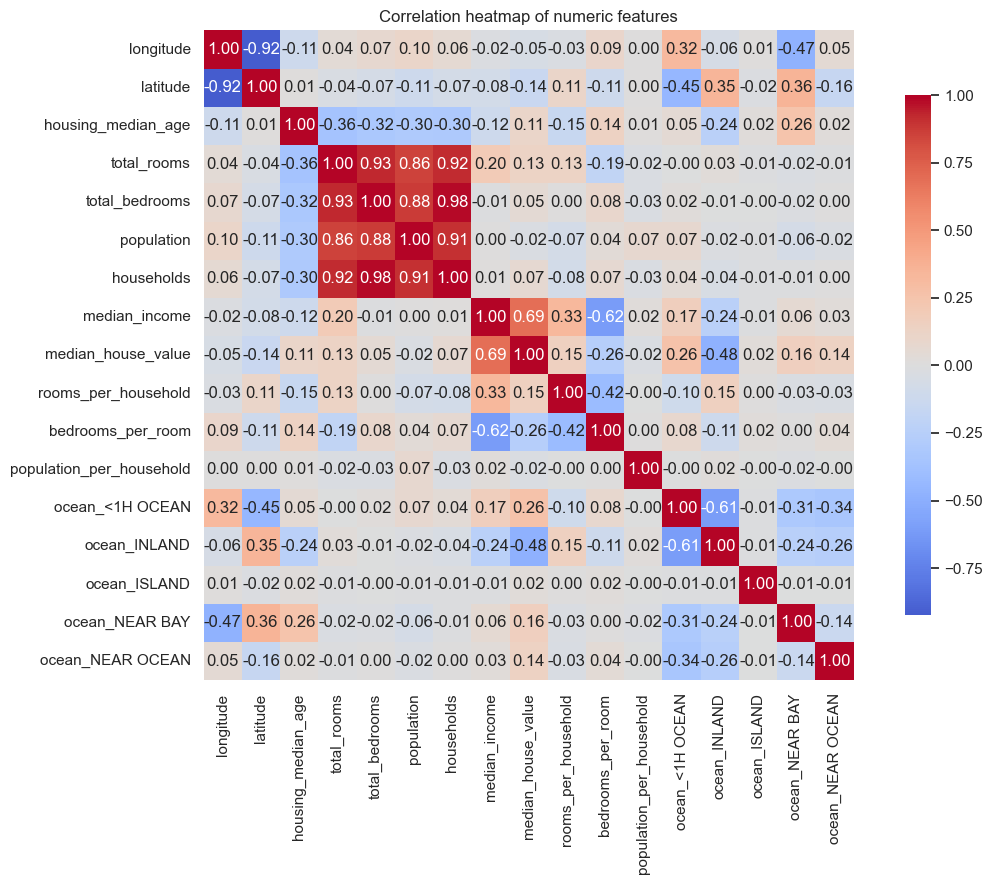

In [11]:
# Stage 5a: Correlation heatmap (numeric features vs target)


# Use numeric columns only; exclude the bookkeeping flag.
num_cols = housing_encoded.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c != "is_capped"]

corr = housing_encoded[num_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap of numeric features")
plt.tight_layout()
plt.savefig("../figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Stage 5b: Verify engineered features (raw total vs ratio)
#
# This is the "demonstrate, don't assert" check: we show the per-household
# ratios correlate MORE strongly with the target than the raw totals do.



target = "median_house_value"

pairs = [
    ("total_rooms",    "rooms_per_household"),
    ("total_bedrooms", "bedrooms_per_room"),
    ("population",      "population_per_household"),
]

print(f"{'feature':<28}{'corr with target':>18}")
print("-" * 46)
for raw, ratio in pairs:
    c_raw   = housing_encoded[raw].corr(housing_encoded[target])
    c_ratio = housing_encoded[ratio].corr(housing_encoded[target])
    print(f"{raw:<28}{c_raw:>18.3f}")
    print(f"  -> {ratio:<24}{c_ratio:>18.3f}")
    print()

print("median_income corr with target: "
      f"{housing_encoded['median_income'].corr(housing_encoded[target]):.3f}  "
      "(strongest single predictor)")

feature                       corr with target
----------------------------------------------
total_rooms                              0.134
  -> rooms_per_household                  0.152

total_bedrooms                           0.050
  -> bedrooms_per_room                   -0.256

population                              -0.025
  -> population_per_household            -0.024

median_income corr with target: 0.688  (strongest single predictor)


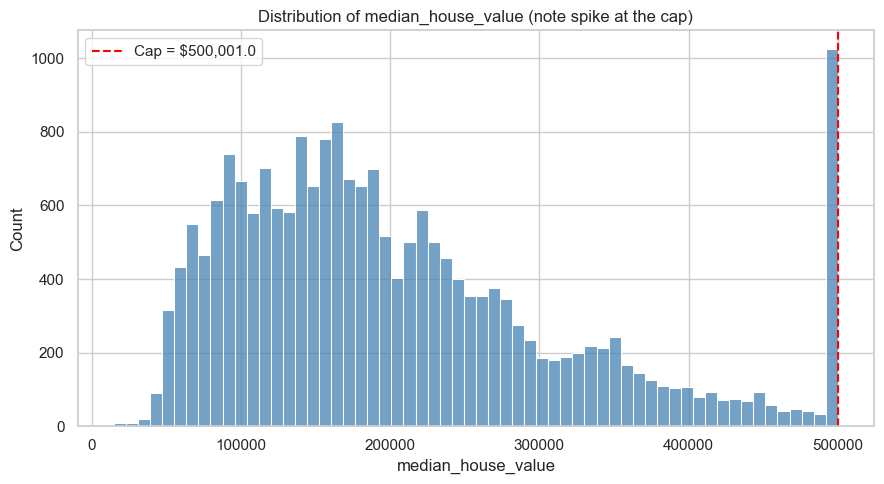

In [13]:
# Stage 5c: Target distribution — visualise the cap artefact



plt.figure(figsize=(9, 5))
sns.histplot(housing_encoded[target], bins=60, kde=False, color="steelblue")
plt.axvline(CAP_VALUE, color="red", linestyle="--",
            label=f"Cap = ${CAP_VALUE:,}")
plt.title("Distribution of median_house_value (note spike at the cap)")
plt.xlabel("median_house_value")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/gy/yhn__ljj2wv3rmhs0pv39lg40000gn/T/ipykernel_9822/1349241441.py:20: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gy/yhn__ljj2wv3rmhs0pv39lg40000gn/T/ipykernel_9822/1349241441.py:21: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig("../figures/geographic_value_map.png", dpi=150, bbox_inches="tight")
/opt/anaconda3/envs/ecmm422/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


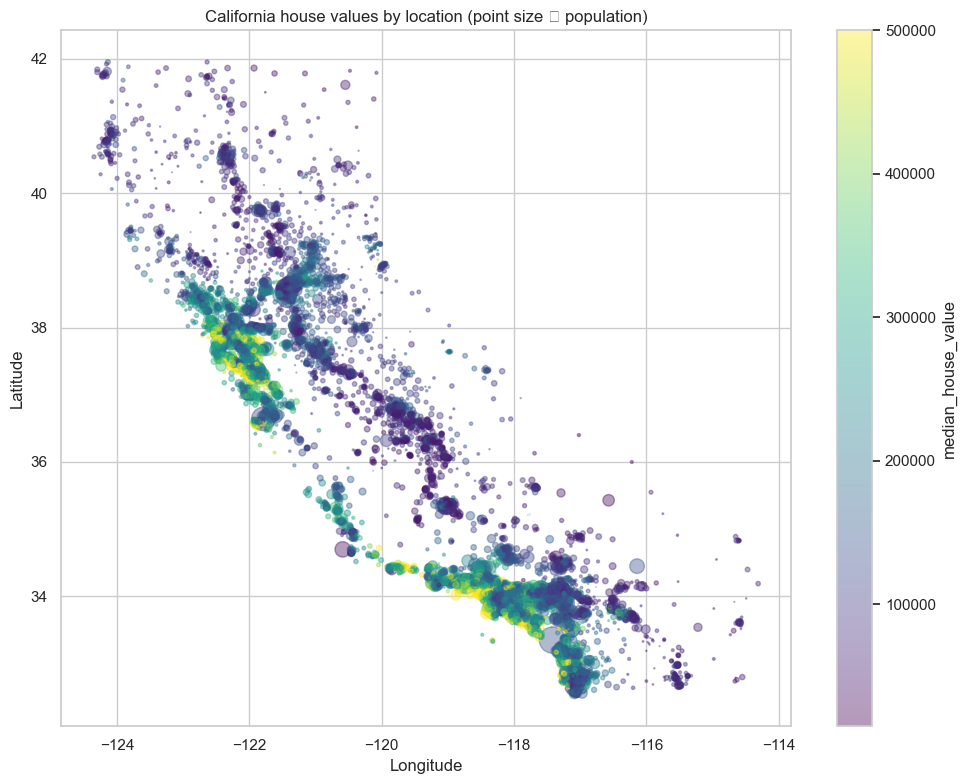

In [14]:
# Stage 5d: Geographic scatter — house value across California
#
# Plots every block group at its real coordinates, coloured by house value
# and sized by population. This reveals strong spatial structure (high values
# on the coast, around the Bay Area and LA) that justifies including latitude/
# longitude as clustering features in Section 7.



plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    housing_encoded["longitude"], housing_encoded["latitude"],
    c=housing_encoded[target], cmap="viridis",
    s=housing_encoded["population"] / 100, alpha=0.4
)
plt.colorbar(scatter, label="median_house_value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California house values by location (point size ∝ population)")
plt.tight_layout()
plt.savefig("../figures/geographic_value_map.png", dpi=150, bbox_inches="tight")
plt.show()